<a href="https://colab.research.google.com/github/damnhuquynhvn-oss/thuchanhdeeplearning/blob/main/Lab03_ph%E1%BA%A7n%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Tải bộ dữ liệu CIFAR10 có sẵn trong tensorflow
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Ép phẳng nhãn thành mảng 1 chiều để xử lý không bị lỗi format
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Kích thước dữ liệu ban đầu:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước dữ liệu ban đầu:
X_train: (50000, 32, 32, 3) y_train: (50000,)
X_test: (10000, 32, 32, 3) y_test: (10000,)


In [3]:
print("=== BƯỚC 1: XỬ LÝ DỮ LIỆU ===")

# 1. Reshape dữ liệu từ 4-D (ảnh 3D) thành 2-D array (duỗi phẳng ảnh)
X_train_flat = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test_flat = X_test.reshape(X_test.shape[0], 32 * 32 * 3)

# 2. Chuẩn hóa tính năng (Feature Scaling) về đoạn [0, 1]
minmax = MinMaxScaler()
X_train_scaled = minmax.fit_transform(X_train_flat)
X_test_scaled = minmax.transform(X_test_flat)

# Định nghĩa danh sách các nhãn của CIFAR10 để tiện đối chiếu
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print('Số lượng lớp (Classes):', len(np.unique(y_train)))
print('Các nhãn mã hóa:', np.unique(y_train))

=== BƯỚC 1: XỬ LÝ DỮ LIỆU ===
Số lượng lớp (Classes): 10
Các nhãn mã hóa: [0 1 2 3 4 5 6 7 8 9]


=== BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU ===


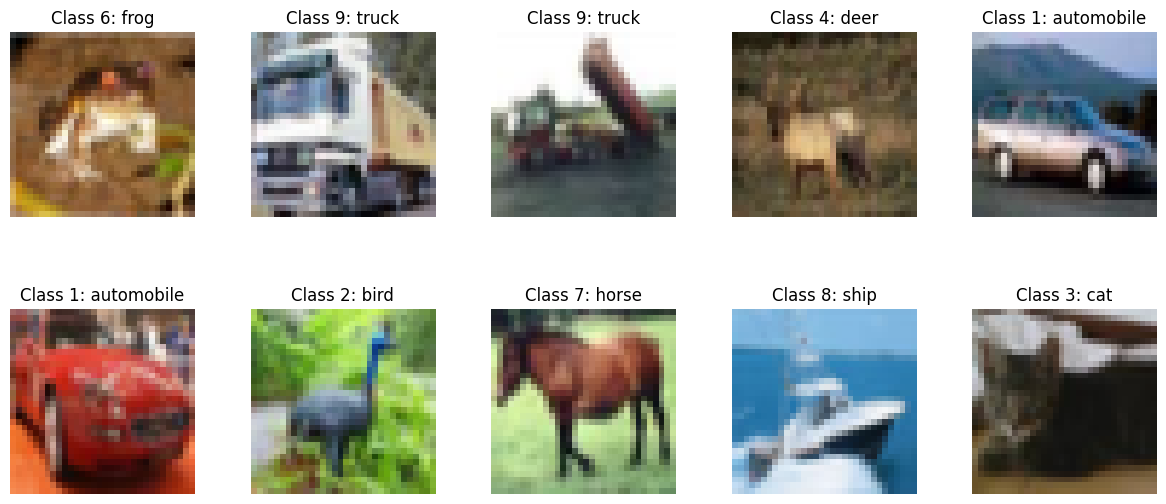

In [4]:
print("=== BƯỚC 2: TRỰC QUAN HÓA DỮ LIỆU ===")
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i]) # Hiển thị ảnh màu gốc chưa reshape
    ax[i].title.set_text(f"Class {y_train[i]}: {class_names[y_train[i]]}")
    ax[i].axis('off')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
print("=== BƯỚC 3: XÂY DỰNG MÔ HÌNH ANN ===")

# Khởi tạo mô hình mạng neural tuần tự
model = Sequential()

# Thêm tầng ẩn thứ nhất (Hidden Layer) sử dụng hàm activation ReLU
model.add(Dense(input_dim=X_train_scaled.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm tầng đầu ra (Output Layer) sử dụng Softmax để phân lớp
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình mạng
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc tổng quan của mạng
model.summary()

=== BƯỚC 3: XÂY DỰNG MÔ HÌNH ANN ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

=== BƯỚC 4: HUẤN LUYỆN MÔ HÌNH ===
Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3289 - loss: 1.8603 - val_accuracy: 0.3718 - val_loss: 1.7752
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3953 - loss: 1.6917 - val_accuracy: 0.3988 - val_loss: 1.6687
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4171 - loss: 1.6331 - val_accuracy: 0.4098 - val_loss: 1.6953
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4323 - loss: 1.5963 - val_accuracy: 0.4372 - val_loss: 1.6039
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.4432 - loss: 1.5678 - val_accuracy: 0.4154 - val_loss: 1.6531
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4470 - loss: 1.5527 - val_accuracy: 0.4338 - val_loss: 1.5893
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4586 - loss: 1.5307 - val_accuracy: 0.4534 - val_loss: 1.5686
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━

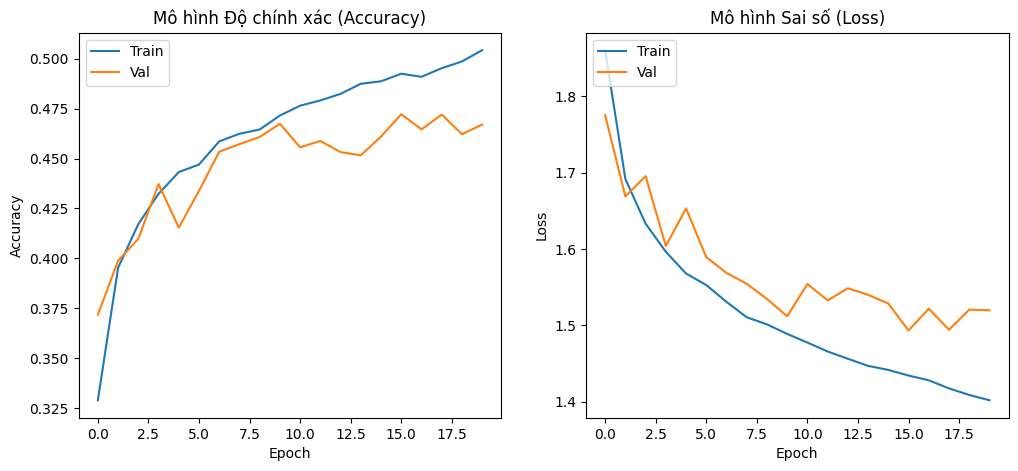

In [6]:
print("=== BƯỚC 4: HUẤN LUYỆN MÔ HÌNH ===")
# Tiến hành fit dữ liệu học
model_fit = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=20, verbose=1)

# --- TRỰC QUAN HÓA ĐỘ CHÍNH XÁC (ACCURACY) ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# --- TRỰC QUAN HÓA SAI SỐ (LOSS) ---
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình Sai số (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.show()

In [7]:
print("=== BƯỚC 5: DỰ BÁO ẢNH NGẪU NHIÊN ===")

# Chọn dự báo thử 3 tấm ảnh ở vị trí Index 0, 10 và 50 trong tập Test
test_indices = [0, 10, 50]

for idx in test_indices:
    # Lấy dữ liệu đã scale đưa vào dự đoán
    sample_data = X_test_scaled[idx].reshape(1, -1)
    prediction = model.predict(sample_data)

    # Tìm nhãn có xác suất cao nhất bằng hàm np.argmax
    predicted_label = np.argmax(prediction)
    true_label = y_test[idx]

    print(f"\n[Ảnh tại Index {idx}]:")
    print(f"-> Mô hình dự đoán là: Lớp {predicted_label} ({class_names[predicted_label]})")
    print(f"-> Nhãn thực tế gốc là: Lớp {true_label} ({class_names[true_label]})")

=== BƯỚC 5: DỰ BÁO ẢNH NGẪU NHIÊN ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

[Ảnh tại Index 0]:
-> Mô hình dự đoán là: Lớp 3 (cat)
-> Nhãn thực tế gốc là: Lớp 3 (cat)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

[Ảnh tại Index 10]:
-> Mô hình dự đoán là: Lớp 8 (ship)
-> Nhãn thực tế gốc là: Lớp 0 (airplane)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

[Ảnh tại Index 50]:
-> Mô hình dự đoán là: Lớp 9 (truck)
-> Nhãn thực tế gốc là: Lớp 9 (truck)
